# 🛡️ Fraud Detection — EDA y Entrenamiento del Modelo

Análisis exploratorio, comparación de 3 modelos (Logistic Regression, Random Forest, XGBoost) con SMOTE, y serialización del modelo final.

**Dataset:** Credit Card Fraud Detection (ULB) — 284,807 transacciones, 0.17% fraude.

In [1]:
# CELDA 1 - Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
# CELDA 2 - Cargar datos
df = pd.read_csv("../data/creditcard.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# CELDA 3 - Exploración básica (EDA)
print("Valores nulos:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())
print("\nDistribución de la clase:")
print(df["Class"].value_counts())
print("\nPorcentaje:")
print(df["Class"].value_counts(normalize=True) * 100)

Valores nulos: 0
Filas duplicadas: 1081

Distribución de la clase:
Class
0    284315
1       492
Name: count, dtype: int64

Porcentaje:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


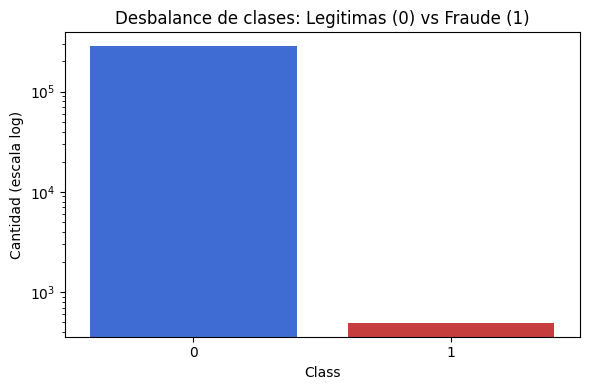

In [ ]:
# CELDA 4 - Visualizar el desbalance
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df, hue="Class", palette=["#2563eb", "#dc2626"], legend=False)
plt.title("Desbalance de clases: Legitimas (0) vs Fraude (1)")
plt.yscale("log")
plt.ylabel("Cantidad (escala log)")
plt.tight_layout()
plt.savefig("../models/class_distribution.png", dpi=120)
plt.show()

In [5]:
# CELDA 5 - Limpieza: eliminar duplicados
df = df.drop_duplicates()
print("Despues de quitar duplicados:", df.shape)

Despues de quitar duplicados: (283726, 31)


In [6]:
# CELDA 6 - Separar features (X) y objetivo (y)
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Fraudes en test:", y_test.sum())

Train: (226980, 30)  Test: (56746, 30)
Fraudes en test: 95


In [7]:
# CELDA 7 - MEJORA 1 y 2: Comparar 3 modelos + SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, confusion_matrix
)

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
}

resultados = []

for nombre, modelo in modelos.items():
    pipe = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("clf", modelo),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    rep = classification_report(y_test, y_pred, output_dict=True)
    resultados.append({
        "Modelo": nombre,
        "Precision (fraude)": round(rep["1"]["precision"], 3),
        "Recall (fraude)": round(rep["1"]["recall"], 3),
        "F1 (fraude)": round(rep["1"]["f1-score"], 3),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 3),
        "PR-AUC": round(average_precision_score(y_test, y_proba), 3),
    })
    print(f"--- {nombre} ---")
    print(classification_report(y_test, y_pred))

tabla = pd.DataFrame(resultados)
tabla

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.75      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746

--- XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.73      0.79      0.76        95

    accuracy                           1.00     56746
   macro avg       0.86      0.89      0.88     56746
weighted

,Modelo,Precision (fraude),Recall (fraude),F1 (fraude),ROC-AUC,PR-AUC
0,Logistic Regression,0.053,0.874,0.100,0.963,0.675
1,Random Forest,0.910,0.747,0.821,0.973,0.815
2,XGBoost,0.728,0.789,0.758,0.970,0.808


In [ ]:
# CELDA 8 - Guardar la tabla comparativa
tabla.to_csv("../models/comparacion_modelos.csv", index=False)
print(tabla.to_markdown(index=False))

| Modelo              |   Precision (fraude) |   Recall (fraude) |   F1 (fraude) |   ROC-AUC |   PR-AUC |
|:--------------------|---------------------:|------------------:|--------------:|----------:|---------:|
| Logistic Regression |                0.053 |             0.874 |         0.1   |     0.963 |    0.675 |
| Random Forest       |                0.91  |             0.747 |         0.821 |     0.973 |    0.815 |
| XGBoost             |                0.728 |             0.789 |         0.758 |     0.97  |    0.808 |


In [10]:
# CELDA 9 - Entrenar el modelo GANADOR y guardarlo
import joblib

modelo_final = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1)),
])
modelo_final.fit(X_train, y_train)

joblib.dump(modelo_final, "../models/fraud_model.pkl")
print("Modelo guardado en models/fraud_model.pkl")

Modelo guardado en models/fraud_model.pkl


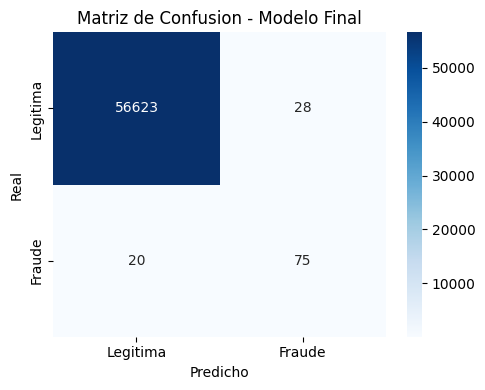

In [ ]:
# CELDA 10 - Matriz de confusion del modelo final 
y_pred_final = modelo_final.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitima", "Fraude"],
            yticklabels=["Legitima", "Fraude"])
plt.title("Matriz de Confusion - Modelo Final")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig("../models/confusion_matrix.png", dpi=120)
plt.show()